<a href="https://colab.research.google.com/github/Himakar06/Employee_Attrition/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
def load_data(path):
    return pd.read_csv(path)

In [3]:
def clean_data(df):
    df.isnull()
    df['BusinessTravel'] = df['BusinessTravel'].str.strip().str.lower()
    df.drop(columns = ['Over18' , 'EmployeeCount'] , inplace = True)
    return df

In [4]:
def engineer_features(df):
    df['EmployeeLevel'] = pd.cut(df['TotalWorkingYears' ],
                                 bins = [0,5,10,40] ,
                                 labels=['Junior','Mid','Senior'])

    df['IsIsingle'] = df['MaritalStatus'].apply(lambda x: 'Yes' if x == 'Single' else 'No')

    return df


In [5]:
def preprocess(df):
    df = pd.get_dummies(df,
                   columns = ['JobRole', 'Department', 'EducationField', 'BusinessTravel'],
                   drop_first = True)

    le = LabelEncoder()
    label_cols = ['Gender','Attrition','OverTime']
    for cols in  label_cols:
      df[cols] = le.fit_transform(df[cols])

    return df

In [6]:
def attrition_vs_overtime(df):
    correlation = df['OverTime'].corr(df['Attrition'])

    sns.barplot(x='OverTime' , y = 'Attrition' , data =df)
    plt.xlabel('OverTime')
    plt.ylabel('Attrition')
    plt.title("OverTime vs Attrition")
    plt.xticks([0,1],['No' ,'Yes'])
    plt.grid(axis = 'y')
    plt.show()

    print(f'Correlation of OverTime with Attrition: {correlation:}')

In [7]:
def main():
    df = load_data('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print('Loaded data')
    display(df.head())
    print(df.info())
    print()

    df = clean_data(df)
    print('Cleaned data')
    display(df.head())

    df = engineer_features(df)
    print("Featured Engineering data")
    display(df.head())

    df = preprocess(df)
    print("Preprocessed data")
    display(df.head())

    attrition_vs_overtime(df)

    return df

Loaded data


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,travel_rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,No,travel_frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,travel_rarely,1373,Research & Development,2,2,Other,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,travel_frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,No,travel_rarely,591,Research & Development,2,1,Medical,7,1,...,4,80,1,6,3,3,2,2,2,2


Featured Engineering data


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EmployeeLevel,IsIsingle
0,41,Yes,travel_rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,8,0,1,6,4,0,5,Mid,Yes
1,49,No,travel_frequently,279,Research & Development,8,1,Life Sciences,2,3,...,1,10,3,3,10,7,1,7,Mid,No
2,37,Yes,travel_rarely,1373,Research & Development,2,2,Other,4,4,...,0,7,3,3,0,0,0,0,Mid,Yes
3,33,No,travel_frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,0,8,3,3,8,7,3,0,Mid,No
4,27,No,travel_rarely,591,Research & Development,2,1,Medical,7,1,...,1,6,3,3,2,2,2,2,Mid,No


Preprocessed data


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Sales Representative,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,BusinessTravel_travel_frequently,BusinessTravel_travel_rarely
0,41,1,1102,1,2,1,2,0,94,3,...,False,False,True,True,False,False,False,False,False,True
1,49,0,279,8,1,2,3,1,61,2,...,False,True,False,True,False,False,False,False,True,False
2,37,1,1373,2,2,4,4,1,92,2,...,False,True,False,False,False,False,True,False,False,True
3,33,0,1392,3,4,5,4,0,56,3,...,False,True,False,True,False,False,False,False,True,False
4,27,0,591,2,1,7,1,1,40,3,...,False,True,False,False,False,True,False,False,False,True


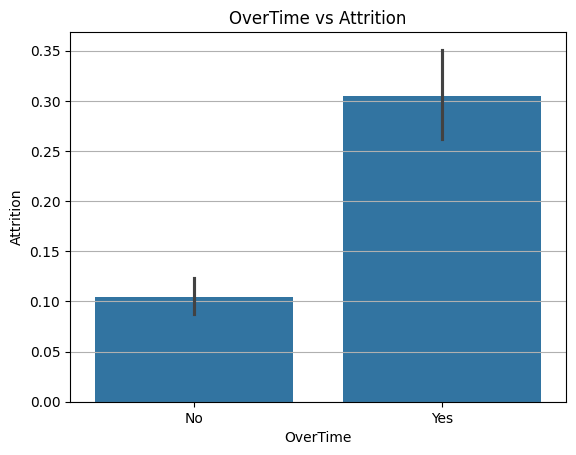

Correlation of OverTime with Attrition: 0.2461179942458032


In [8]:
df_final = main()